In [11]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

img = np.asarray(Image.open("./notes/example.png"))
h = img.shape[0]
w = img.shape[1]
img = img[:, :, :3]
# h x w x 3 (remove alpha)

m = h * w

X = img.reshape(m, 3)
X.shape

(1079808, 3)

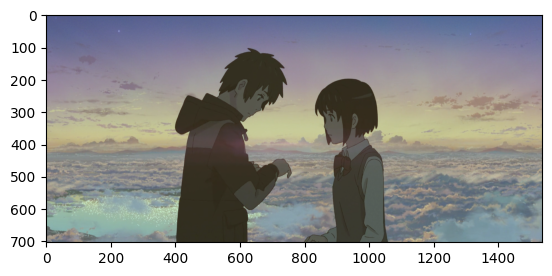

In [24]:
# each column is r, g, b, a
# now let's do pca!

mean = X.mean(axis=0)
std = X.std(axis=0)
DX = X - mean
DX /= std

# DX is normalized x
# normalized/adjusted plot!
plt.imshow((DX.reshape(h, w, 3) + 3) / 6, cmap='gray')

In [34]:
U, S, Vt = np.linalg.svd(DX, full_matrices=False)

# now let's only take the most important component:
S_prime = np.zeros((S.shape[0], S.shape[0]))
np.fill_diagonal(S_prime, S[:1])
DX_prime = U @ S_prime @ Vt

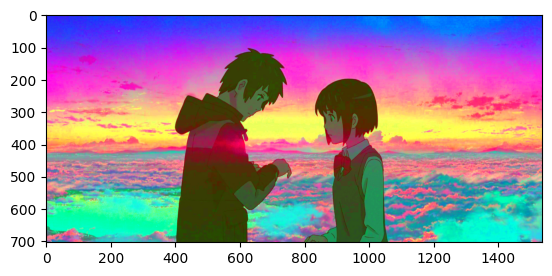

In [ ]:
# unnormalize:
X_prime = DX_prime * std + mean
# disappointing clip
X_prime = np.clip(X_prime, 0, 255).astype(np.uint8)
plt.imshow(X_prime.reshape(h, w, 3))

# everything is blown out because we want to see the most variation -> color change